# Revenue Tree Gallery

The revenue tree decomposes a period-on-period change in revenue into the multiplicative drivers that produced it: customers, visits per customer, items per visit, and price per item. Each node shows the value in both periods, the absolute and percentage change, and the contribution that driver made to the total revenue change.

Revenue trees excel at:
- **Performance diagnostics**: pinpoint which lever moved when revenue shifts year-on-year
- **Strategic planning**: identify the largest leverage points before setting next year's targets
- **Store and region comparisons**: spot whether two units share a story or differ in what's driving them
- **Pricing vs. volume attribution**: separate how much of a revenue lift came from charging more vs. selling more units

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from openretailscience.analysis.revenue_tree import RevenueTree

In [ ]:
# Hand-crafted demo datasets shared across the gallery examples.
# Each row is one transaction; the revenue tree aggregates with nunique(customer_id),
# the customer, transaction, spend and quantity columns. Counts and per-row
# values are chosen so the resulting KPIs are exact, not statistical.


def _build_period(
    label: str,
    customer_id_start: int,
    transaction_id_start: int,
    n_customers: int,
    visits_split: tuple[int, int],
    spend_per_visit: float,
    units_per_visit: int,
    region: str | None = None,
) -> pd.DataFrame:
    # visits_split=(low, high) means half the customers do `low` visits, half do `high`.
    low_visits, high_visits = visits_split
    half = n_customers // 2
    visits_per_customer = np.concatenate(
        [
            np.full(half, low_visits),
            np.full(n_customers - half, high_visits),
        ]
    )
    customer_ids = np.arange(customer_id_start, customer_id_start + n_customers)
    customer_col = np.repeat(customer_ids, visits_per_customer)
    n_visits = customer_col.size
    df = pd.DataFrame(
        {
            "customer_id": customer_col,
            "transaction_id": np.arange(transaction_id_start, transaction_id_start + n_visits),
            "unit_spend": np.full(n_visits, spend_per_visit),
            "unit_quantity": np.full(n_visits, units_per_visit),
            "period": label,
        }
    )
    if region is not None:
        df["region"] = region
    return df


# --- Single-tree dataset ----------------------------------------------------
# 2023: 100 customers, 850 visits, $48 / visit, 4 units / visit
#       => $40,800 revenue, $408 / customer, 8.5 visits / customer, $12 / unit
# 2024: 110 customers, 825 visits, $54 / visit, 4 units / visit
#       => $44,550 revenue, $405 / customer, 7.5 visits / customer, $13.50 / unit
# Story: revenue +9.2%. More customers and bigger baskets offset a drop in visit frequency.
_p1 = _build_period(
    label="2023",
    customer_id_start=10_000,
    transaction_id_start=100_000,
    n_customers=100,
    visits_split=(8, 9),
    spend_per_visit=48.0,
    units_per_visit=4,
)
_p2 = _build_period(
    label="2024",
    customer_id_start=20_000,
    transaction_id_start=200_000,
    n_customers=110,
    visits_split=(7, 8),
    spend_per_visit=54.0,
    units_per_visit=4,
)
transactions = pd.concat([_p1, _p2], ignore_index=True)

# --- Same dataset, unit_quantity removed (forces the 5-node layout) ----------
transactions_no_quantity = transactions.drop(columns=["unit_quantity"])

# --- Multi-region dataset for group_col + row_index --------------------------
# Two regions tell opposite stories so the same tree shape lands two different headlines:
#   North: customers up, prices up, revenue up.   2023 $24,480 -> 2024 $28,350 (+15.8%)
#   South: customers flat, prices flat, fewer visits, revenue down.
#                                                  2023 $16,320 -> 2024 $14,400 (-11.8%)
_north_p1 = _build_period(
    label="2023",
    customer_id_start=30_000,
    transaction_id_start=300_000,
    n_customers=60,
    visits_split=(8, 9),
    spend_per_visit=48.0,
    units_per_visit=4,
    region="North",
)
_north_p2 = _build_period(
    label="2024",
    customer_id_start=40_000,
    transaction_id_start=400_000,
    n_customers=70,
    visits_split=(7, 8),
    spend_per_visit=54.0,
    units_per_visit=4,
    region="North",
)
_south_p1 = _build_period(
    label="2023",
    customer_id_start=50_000,
    transaction_id_start=500_000,
    n_customers=40,
    visits_split=(8, 9),
    spend_per_visit=48.0,
    units_per_visit=4,
    region="South",
)
_south_p2 = _build_period(
    label="2024",
    customer_id_start=60_000,
    transaction_id_start=600_000,
    n_customers=40,
    visits_split=(7, 8),
    spend_per_visit=48.0,
    units_per_visit=4,
    region="South",
)
regional_transactions = pd.concat(
    [_north_p1, _north_p2, _south_p1, _south_p2],
    ignore_index=True,
)

## Default Tree

When `unit_quantity` is present in the data, `draw_tree()` renders the full eight-node tree, splitting the spend-per-visit branch further into units per visit and price per unit. Cells whose driver helped revenue render green, cells that hurt revenue render red, and cells with sub-1% movement render gray, so the eye lands on the levers that actually moved.

Pass `value_labels=(current, previous)` to label the two periods. The first entry labels the period 2 column, the second labels period 1.

---

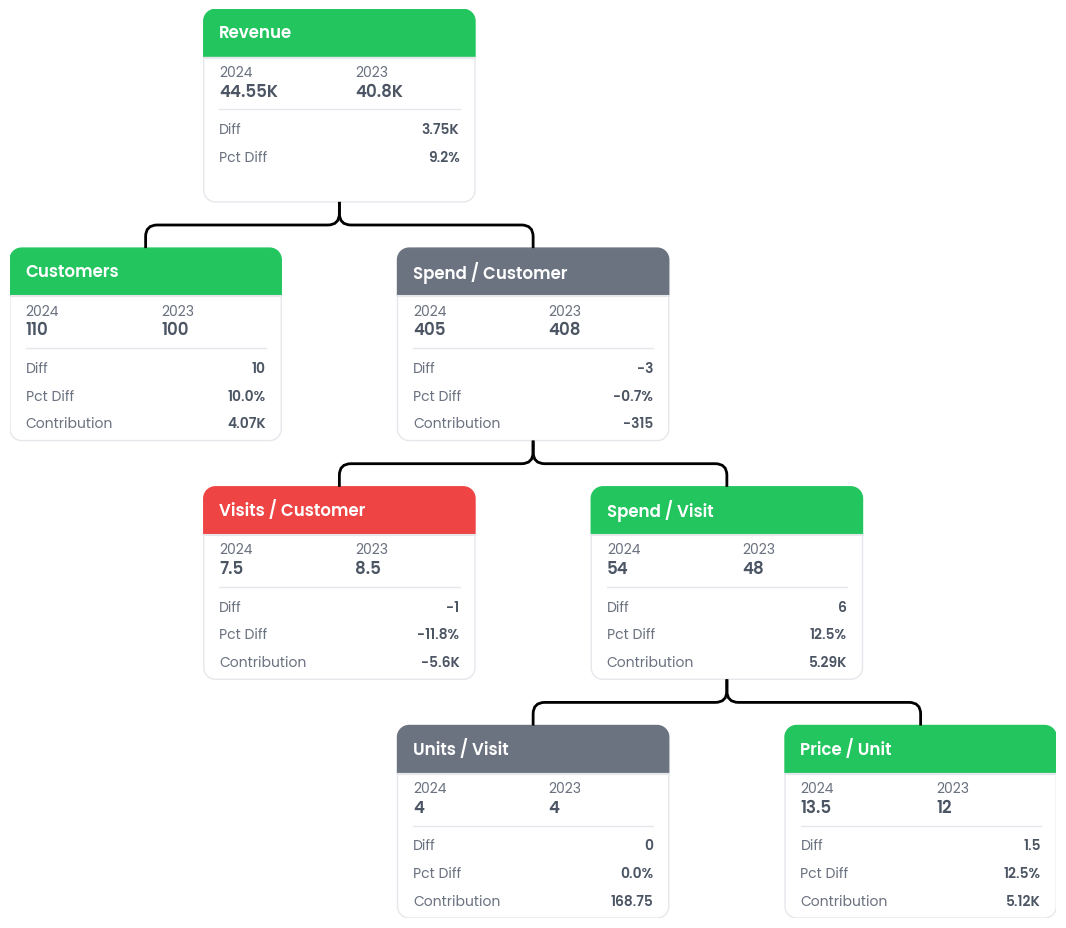

In [ ]:
rt = RevenueTree(
    df=transactions,
    period_col="period",
    p1_value="2023",
    p2_value="2024",
)
rt.draw_tree(value_labels=("2024", "2023"))
plt.show()

## Custom Node Labels

Each node label is a separate parameter on `draw_tree()`, so you can rename any subset to match your team's vocabulary without touching the underlying analysis. The shape of the tree stays the same. Useful when "Revenue" should read as "Sales", "Customers" should read as "Shoppers", or "Visit" maps to operational language like "Trip", "Order", or "Session".

---

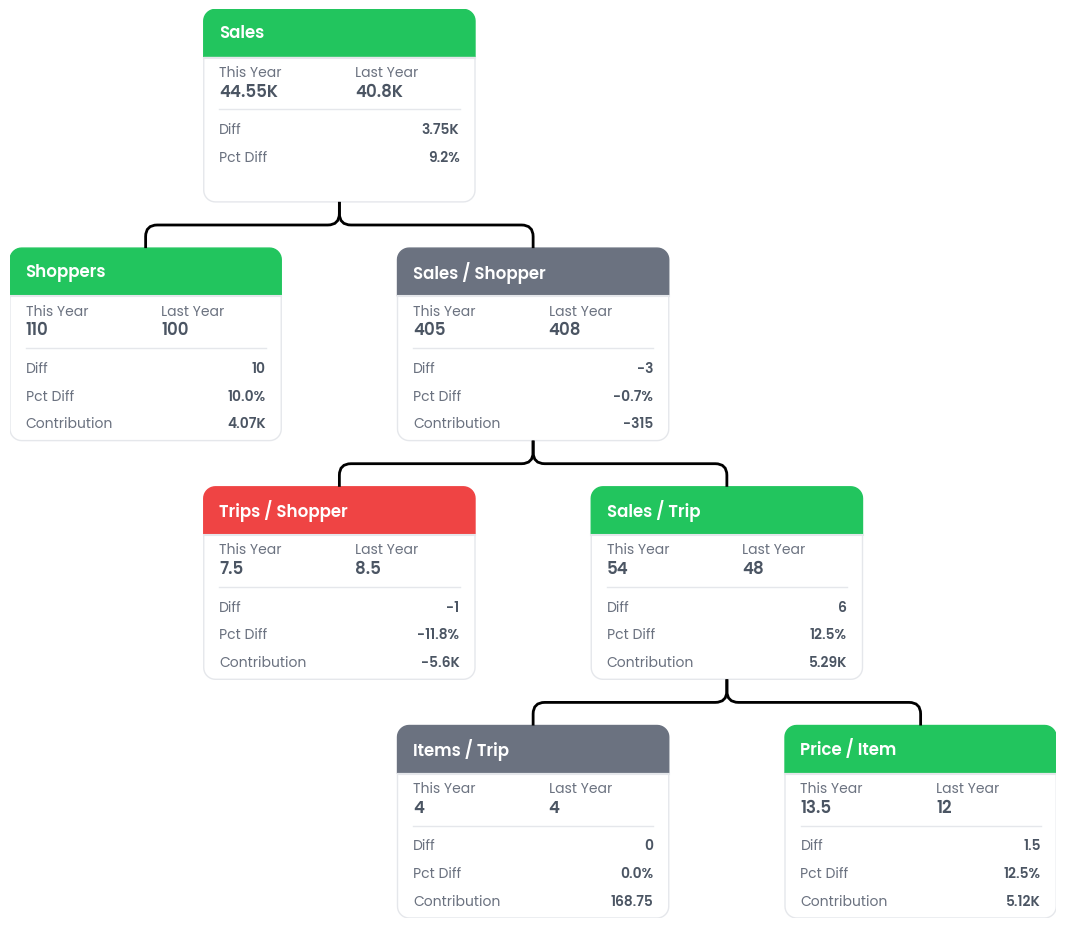

In [ ]:
rt.draw_tree(
    value_labels=("This Year", "Last Year"),
    unit_spend_label="Sales",
    customer_id_label="Shoppers",
    spend_per_customer_label="Sales / Shopper",
    transactions_per_customer_label="Trips / Shopper",
    spend_per_transaction_label="Sales / Trip",
    units_per_transaction_label="Items / Trip",
    price_per_unit_label="Price / Item",
)
plt.show()

## Five-Node Tree

When `unit_quantity` isn't in the input data, `draw_tree()` renders a five-node tree that stops at spend per visit. Use this shape when the upstream system only tracks transaction totals (no item-level data), or when the units-versus-price split isn't relevant to the audience and a simpler tree communicates faster.

---

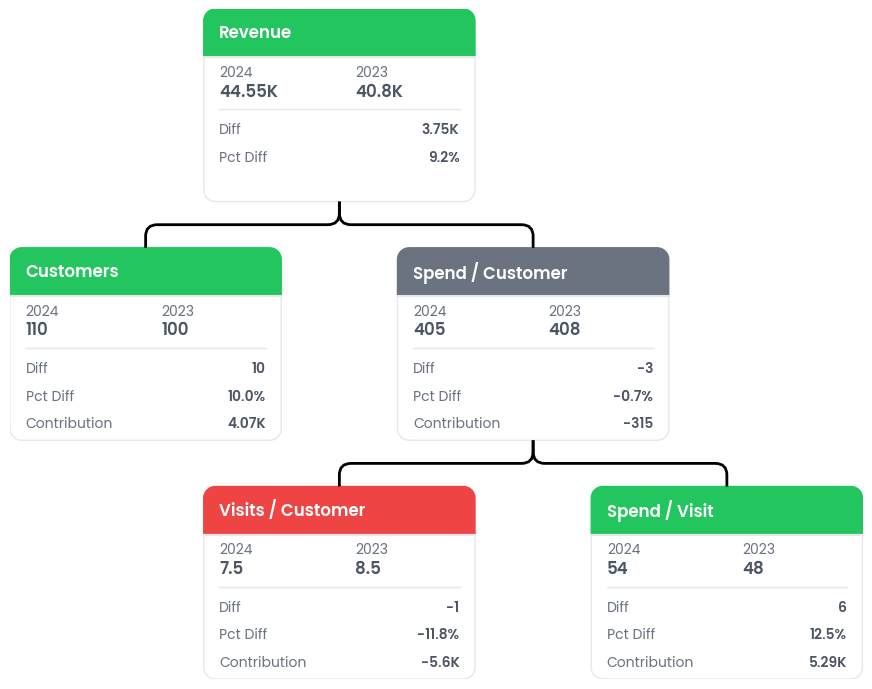

In [ ]:
rt_no_quantity = RevenueTree(
    df=transactions_no_quantity,
    period_col="period",
    p1_value="2023",
    p2_value="2024",
)
rt_no_quantity.draw_tree(value_labels=("2024", "2023"))
plt.show()

## Grouped Trees with `group_col` and `row_index`

Pass `group_col` to compute one tree per group (region, store, segment, channel). The class still holds a single DataFrame, but each row corresponds to one group's KPIs. Render any group's tree by passing `row_index=N` to `draw_tree()`: index `0` is the first group, `1` is the second, and so on. Useful for side-by-side comparisons where two units of the business have moved in opposite directions.

---

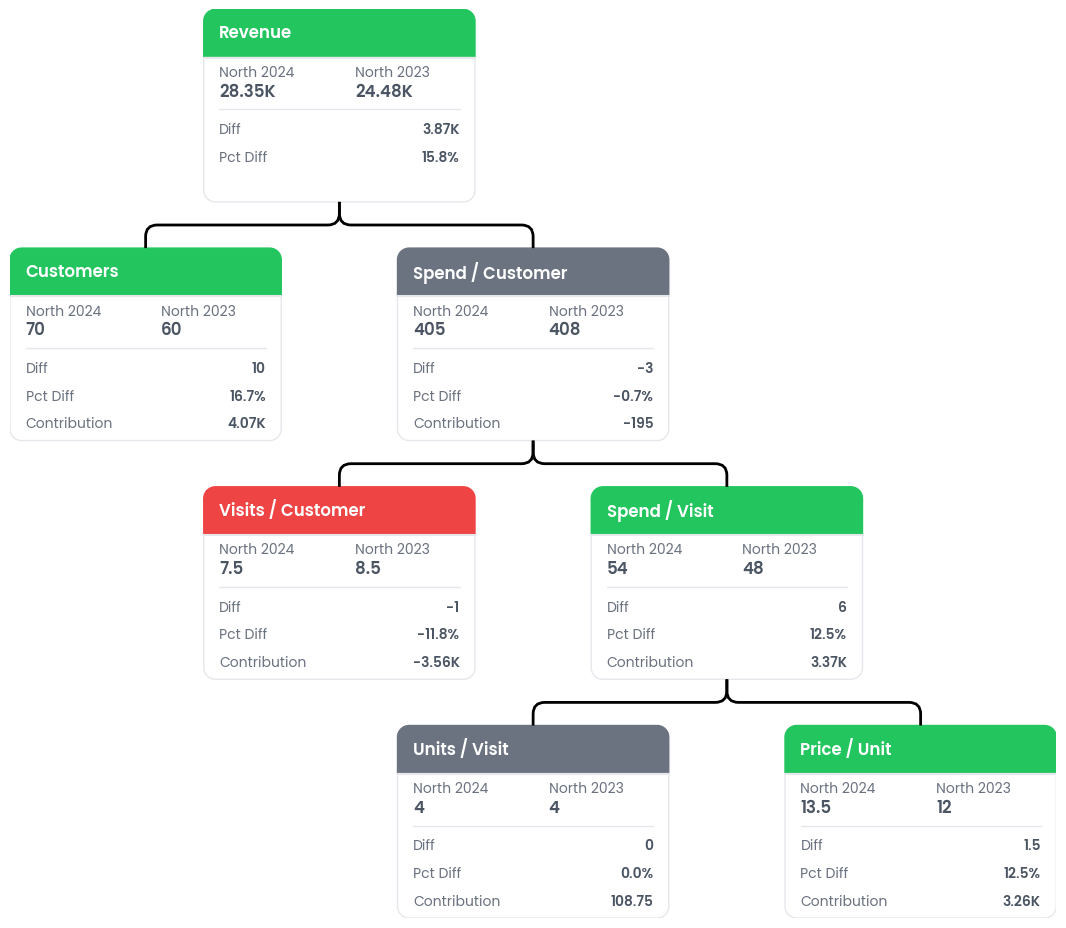

In [ ]:
rt_regional = RevenueTree(
    df=regional_transactions,
    period_col="period",
    p1_value="2023",
    p2_value="2024",
    group_col="region",
)
# Index 0 -> North (sorted alphabetically). Revenue +15.8%, driven by new shoppers and higher prices.
rt_regional.draw_tree(row_index=0, value_labels=("North 2024", "North 2023"))
plt.show()

Switching to `row_index=1` renders the same tree shape for the next group, surfacing a different story without any change to the analysis. South customers held flat but visited less often, and prices didn't move to compensate.

---

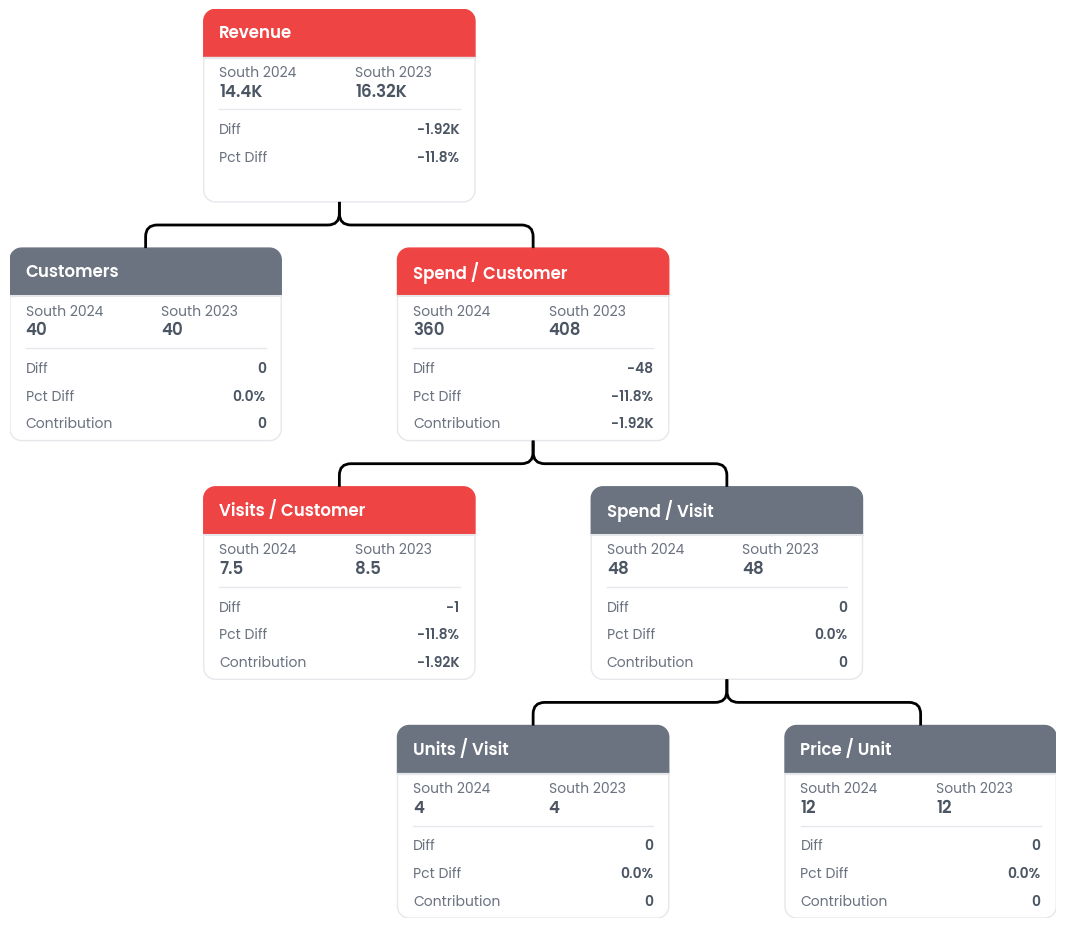

In [ ]:
rt_regional.draw_tree(row_index=1, value_labels=("South 2024", "South 2023"))
plt.show()